## Analytical Solution
#### Using Sisson 1987
##### Brooks-Corey and ROSETTA/van Genuchten Parameters

In [153]:
import numpy as np
import matplotlib.pyplot as plt

##### ROSETTA/vG style soil parameter table

In [154]:
soils = {
    "sand": {
        "theta_r": 0.045,
        "theta_s": 0.43,
        "alpha": 0.145,
        "vg_n": 2.68,
        "Ks": 29.7,
    },
    "loamy_sand": {
        "theta_r": 0.057,
        "theta_s": 0.41,
        "alpha": 0.124,
        "vg_n": 2.28,
        "Ks": 14.6,
    },
    "sandy_loam": {
        "theta_r": 0.065,
        "theta_s": 0.41,
        "alpha": 0.075,
        "vg_n": 1.89,
        "Ks": 4.42,
    },
    "loam": {
        "theta_r": 0.078,
        "theta_s": 0.43,
        "alpha": 0.036,
        "vg_n": 1.56,
        "Ks": 1.04,
    },
    "silt": {
        "theta_r": 0.085,
        "theta_s": 0.45,
        "alpha": 0.025,
        "vg_n": 1.35,
        "Ks": 0.52,
    }       
}


### Brooks-Corey Conductivity

In [155]:
def K_brooks_corey(theta, theta_c, theta_m, K_m, bc_n):
    Se = (theta - theta_c) / (theta_m - theta_c)
    Se = np.clip(Se, 0, 1)

    K = K_m * Se ** (1 / bc_n)

    return K

##### Conversion of van Genuchten n to Brooks-Corey n

In [156]:
def vg_to_bc_n(vg_n):
    """
    Placeholder conversion from van Genuchten n to Brooks-Corey/Sisson n.
    This should be checked before final thesis use.

    1 / (vg_n - 1) """
# The vG-to-Brooks-Corey conversion is currently provisional.
# The relationship bc_n = 1/(vg_n - 1) becomes unstable when vg_n is near 2
# and can produce unrealistic analytical profiles.

    return vg_n


##### Analytical Solution

In [157]:
def theta_brooks_corey_sisson(z, t, theta_r, theta_s, Ks, bc_n):
    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    s = np.maximum(z / t, 1e-12)

    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / (1 / bc_n - 1)

    Se = (s / A) ** exponent
    theta_raw = theta_r + Se * (theta_s - theta_r)

    theta = np.clip(theta_raw, theta_r, theta_s)

    return theta_raw

In [158]:
def theta_brooks_corey_sisson_piecewise(
        z, t, theta_r, theta_s, Ks, bc_n, q0,
        return_star_mid=False,
        debug=False):

    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    # Transformed depth for saturated initial condition
    z_star = (Ks / q0) ** bc_n * z

    # Sisson variable: z*/t
    s_star = np.maximum(z_star / t, 1e-12)

    # Brooks-Corey derivative setup
    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / ((1 / bc_n) - 1)

    # Middle transformed solution
    theta_star_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent

    if debug:
        print("bc_n =", bc_n)
        print("Ks =", Ks)
        print("q0 =", q0)
        print("A =", A)
        print("exponent =", exponent)
        print("z_star min =", z_star.min())
        print("z_star max =", z_star.max())
        print("s_star min =", s_star.min())
        print("s_star max =", s_star.max())
        print("theta_star_mid min =", theta_star_mid.min())
        print("theta_star_mid max =", theta_star_mid.max())

    if return_star_mid:
        return theta_star_mid

    # Piecewise solution based on Sisson Eq. 15
    theta_star = np.empty_like(z)

    theta_star = np.clip(theta_star_mid, theta_r, theta_s)

    return theta_star

    """# For Brooks-Corey with bc_n < 1:
    # K'(theta_r) = 0 approximately
    # K'(theta_s) = A
    A_min = 0.0
    A_max = A

    drained = s_star <= A_min
    middle = (s_star > A_min) & (s_star < A_max)
    unchanged = s_star >= A_max

    theta_star[drained] = theta_r
    theta_star[middle] = theta_star_mid[middle]
    theta_star[unchanged] = theta_s

    # Safety bounds, but this should no longer be doing the main work
    theta_star = np.clip(theta_star, theta_r, theta_s)

    return theta_star""" 

In [159]:
""" def theta_brooks_corey_sisson_piecewise(
        z, t, theta_r, theta_s, Ks, bc_n, q0,
        return_star_mid=False):

    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    # Step 3: transformed depth for saturated initial profile
    z_star = (Ks / q0) ** bc_n * z

    # Step 5: middle solution in transformed coordinates
    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / ((1 / bc_n) - 1)

    s_star = np.maximum(z_star / t, 1e-12)

    theta_star_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent

    if return_star_mid:
        return theta_star_mid

    # Piecewise limits from Sisson Eq. 15
    theta_star = np.empty_like(z)

    theta_star[theta_star_mid <= theta_r] = theta_r
    theta_star[theta_star_mid >= theta_s] = theta_s

    middle = (theta_star_mid > theta_r) & (theta_star_mid < theta_s)
    theta_star[middle] = theta_star_mid[middle]

    # For saturated initial condition and θm = θs, θ* maps directly for this simplified first version
    theta = theta_star

    return theta """

' def theta_brooks_corey_sisson_piecewise(\n        z, t, theta_r, theta_s, Ks, bc_n, q0,\n        return_star_mid=False):\n\n    z = np.asarray(z, dtype=float)\n\n    if t <= 0:\n        return np.full_like(z, theta_s)\n\n    # Step 3: transformed depth for saturated initial profile\n    z_star = (Ks / q0) ** bc_n * z\n\n    # Step 5: middle solution in transformed coordinates\n    A = Ks / (bc_n * (theta_s - theta_r))\n    exponent = 1 / ((1 / bc_n) - 1)\n\n    s_star = np.maximum(z_star / t, 1e-12)\n\n    theta_star_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent\n\n    if return_star_mid:\n        return theta_star_mid\n\n    # Piecewise limits from Sisson Eq. 15\n    theta_star = np.empty_like(z)\n\n    theta_star[theta_star_mid <= theta_r] = theta_r\n    theta_star[theta_star_mid >= theta_s] = theta_s\n\n    middle = (theta_star_mid > theta_r) & (theta_star_mid < theta_s)\n    theta_star[middle] = theta_star_mid[middle]\n\n    # For saturated initial condition and 

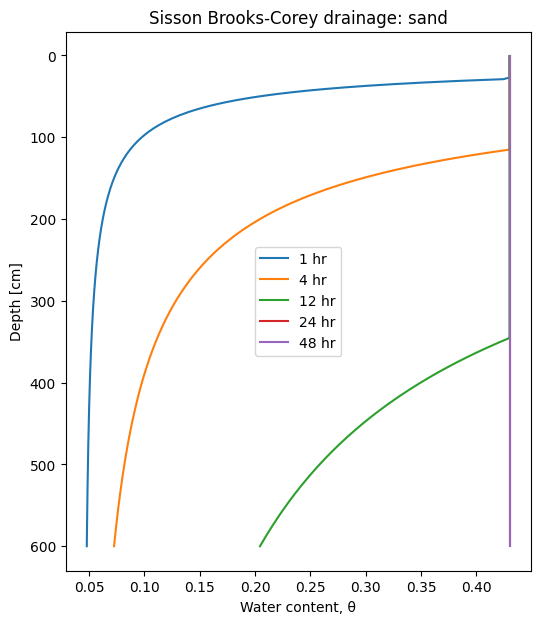

'for q0 in q0_values:\n    theta = theta_brooks_corey_sisson_piecewise(\n        z=z,\n        t=1,\n        theta_r=soil["theta_r"],\n        theta_s=soil["theta_s"],\n        Ks=soil["Ks"],\n        bc_n=bc_n,\n        q0=q0\n    )\n\n    plt.plot(theta, z, label=f"q0={q0}")\n\nplt.gca().invert_yaxis()\nplt.xlabel("Water content, θ")\nplt.ylabel("Depth [cm]")\nplt.title("Sensitivity to q0, loamy sand, 1 hr")\nplt.legend()\nplt.show()'

In [ ]:
soil_name = "sand"
soil = soils[soil_name]

bc_n = vg_to_bc_n(soil["vg_n"])
q0 = soil["Ks"]

times = [1, 4, 12, 24, 48]

plt.figure(figsize=(6, 7))

for t in times:
    theta = theta_brooks_corey_sisson_piecewise(
        z=z,
        t=t,
        theta_r=soil["theta_r"],
        theta_s=soil["theta_s"],
        Ks=soil["Ks"],
        bc_n=bc_n,
        q0=q0,
        debug=False
    )

    plt.plot(theta, z, label=f"{t} hr")

plt.gca().invert_yaxis()
plt.xlabel("Water content, θ")
plt.ylabel("Depth [cm]")
plt.title(f"Sisson Brooks-Corey drainage: {soil_name}")
plt.legend()
plt.show()


DEBUGGING PLOT CELL

theta_star_mid min: 0.057149167131837535
theta_star_mid max: 13.308195276295502
bc_n: 2.28
theta_mid min: 0.057149167131837535
theta_mid max: 13.308195276295502


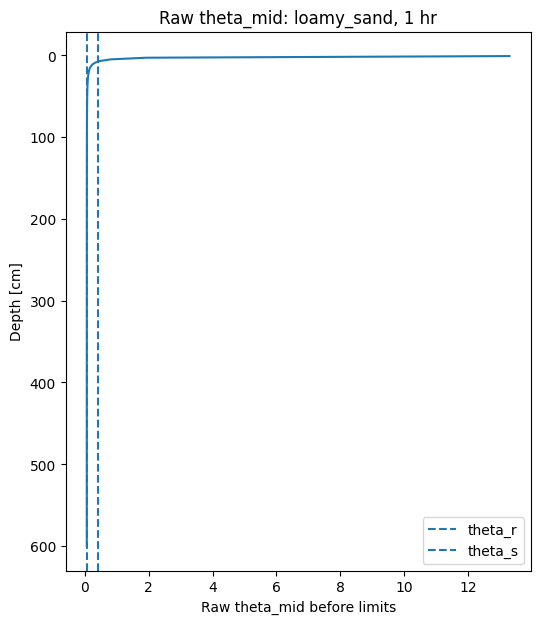

In [163]:
soil_name = "loamy_sand"
soil = soils[soil_name]
bc_n = vg_to_bc_n(soil["vg_n"])

t_debug = 1  # hr

q0 = 10.0  # cm/hr, initial steady flux

theta_star_mid = theta_brooks_corey_sisson_piecewise(
    z=z,
    t=1,
    theta_r=soil["theta_r"],
    theta_s=soil["theta_s"],
    Ks=soil["Ks"],
    bc_n=bc_n,
    q0=q0,
    return_star_mid=True
)

print("theta_star_mid min:", theta_star_mid.min())
print("theta_star_mid max:", theta_star_mid.max())

print("bc_n:", bc_n)
print("theta_mid min:", theta_star_mid.min())
print("theta_mid max:", theta_star_mid.max())

plt.figure(figsize=(6, 7))
plt.plot(theta_star_mid, z)
plt.axvline(soil["theta_r"], linestyle="--", label="theta_r")
plt.axvline(soil["theta_s"], linestyle="--", label="theta_s")
plt.gca().invert_yaxis()
plt.xlabel("Raw theta_mid before limits")
plt.ylabel("Depth [cm]")
plt.title(f"Raw theta_mid: {soil_name}, {t_debug} hr")
plt.legend()
plt.show()

#### Plot for one soil first

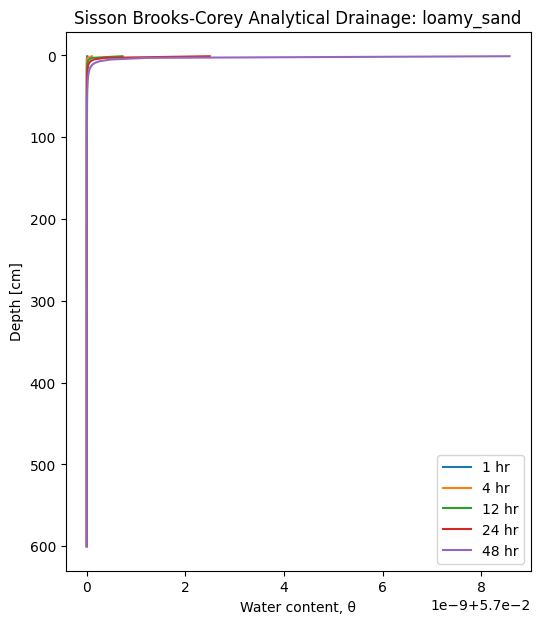

In [164]:
z = np.linspace(1, 600, 300)  # cm, positive downward
times = [1, 4, 12, 24, 48]   # hr

soil_name = "loamy_sand"
soil = soils[soil_name]
bc_n = vg_to_bc_n(soil["vg_n"])

plt.figure(figsize=(6, 7))

for t in times:
    q0 = 0.01  # cm/hr, initial steady flux

    theta = theta_brooks_corey_sisson_piecewise(
        z=z,
        t=t,
        theta_r=soil["theta_r"],
        theta_s=soil["theta_s"],
        Ks=soil["Ks"],
        bc_n=bc_n,
        q0=q0
    )
    plt.plot(theta, z, label=f"{t} hr")

plt.gca().invert_yaxis()
plt.xlabel("Water content, θ")
plt.ylabel("Depth [cm]")
plt.title(f"Sisson Brooks-Corey Analytical Drainage: {soil_name}")
plt.legend()
plt.show()

#### Plot for all soils 

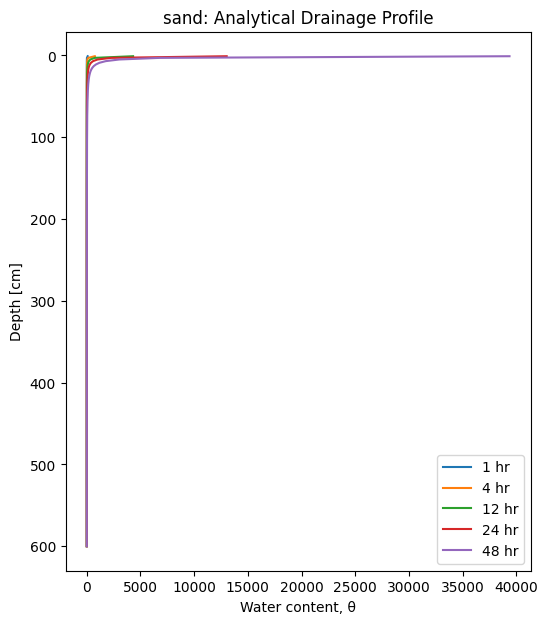

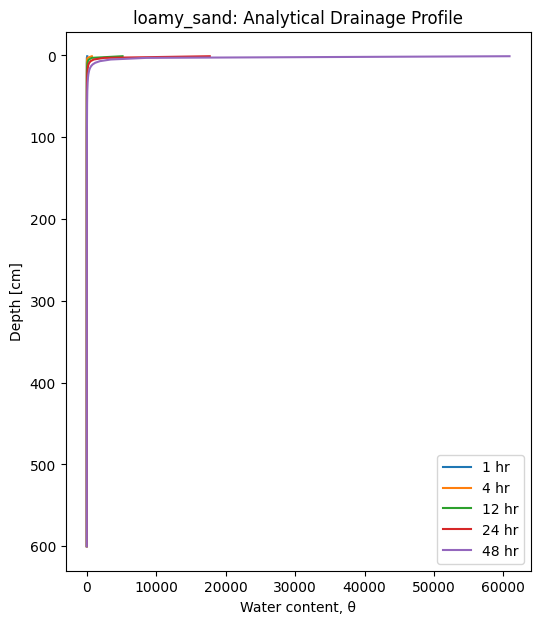

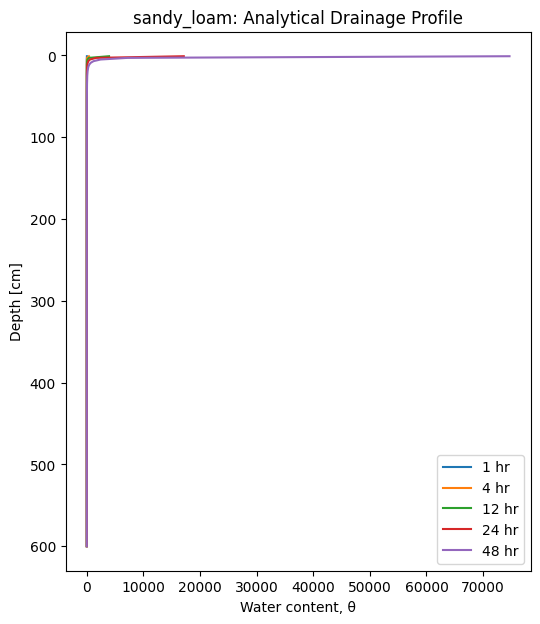

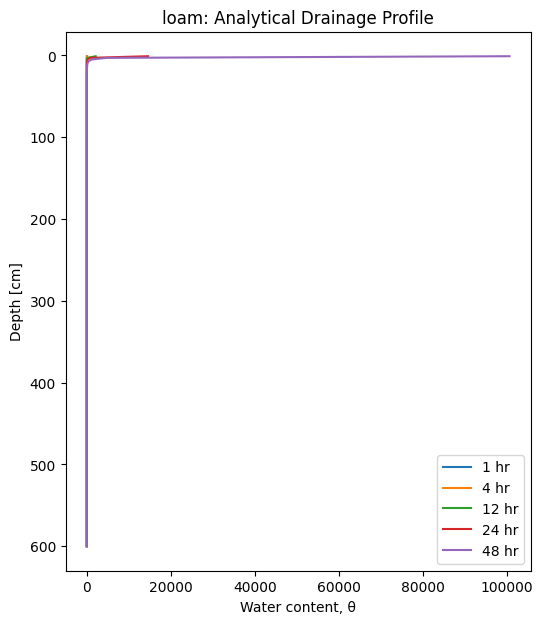

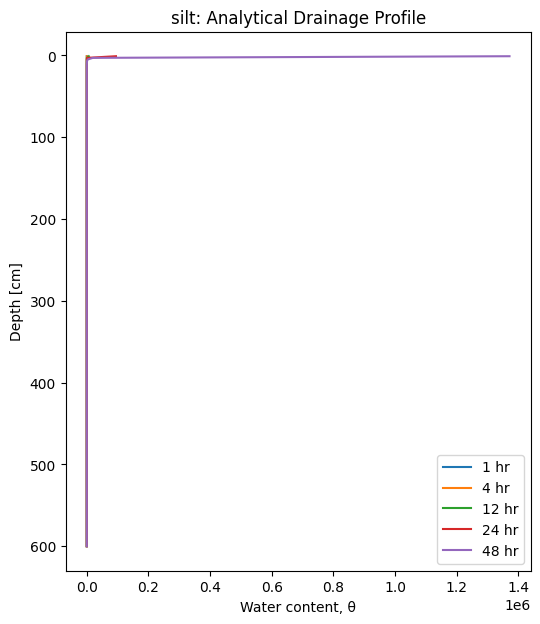

In [165]:
for soil_name, soil in soils.items():
    bc_n = vg_to_bc_n(soil["vg_n"])

    plt.figure(figsize=(6, 7))

    for t in times:
        theta = theta_brooks_corey_sisson(
            z=z,
            t=t,
            theta_r=soil["theta_r"],
            theta_s=soil["theta_s"],
            Ks=soil["Ks"],
            bc_n=bc_n
        )
        plt.plot(theta, z, label=f"{t} hr")

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, θ")
    plt.ylabel("Depth [cm]")
    plt.title(f"{soil_name}: Analytical Drainage Profile")
    plt.legend()
    plt.show()